In [ ]:
import joblib              as jlb
import matplotlib.pyplot   as plt
import numpy               as np
if not hasattr(np, 'warnings'):
    np.warnings = np
if not hasattr(np, 'filterwarnings'):
    np.filterwarnings = lambda *args, **kwargs: None
import pandas              as pd
import seaborn             as sbn
import warnings
warnings.filterwarnings('ignore') # tắt những cảnh báo

from collections                      import Counter
from sklearn.preprocessing            import LabelEncoder
from pyclustering.cluster.kmedoids    import kmedoids
from pyclustering.cluster.center_initializer import kmeans_plusplus_initializer
from sklearn.preprocessing     import LabelEncoder
from sklearn.metrics           import pairwise_distances
from Customer_dataset import data
processed_data=data.copy()

Tiền xử lý dữ liệu

In [2]:
print('Shape:', processed_data.shape)
print()
print(processed_data.dtypes)

Shape: (1000, 3)

Age             int64
Income_Level    int64
Gender_Male     int64
dtype: object


In [3]:
## Bỏ các cột không phù hợp để gom cụm
## - Customer ID      : định danh, không mang thông tin phân cụm
## - Purchase History : chuỗi ngày tháng dạng text
## - Segmentation Group : nhãn gốc (unsupervised nên không dùng)
# drop_cols  = ['Customer ID', 'Purchase History', 'Segmentation Group']
# data_model = processed_data.drop(columns = drop_cols).copy()
data_model = processed_data.copy()
print(data_model.head())

   Age  Income_Level  Gender_Male
0   23         70541            0
1   26         54168            1
2   29         73899            0
3   20         63381            1
4   25         38794            0


In [7]:
## Encode toàn bộ cột categorical sang dạng số
le = LabelEncoder()
for col in data_model.select_dtypes(include = 'object').columns:
    data_model[col] = le.fit_transform(data_model[col].astype(str))

print(data_model.head())

   Age  Gender  Marital Status  Education Level  Geographic Information  \
0   23       0               1                0                      22   
1   26       1               4                2                      10   
2   29       0               3                0                      27   
3   20       1               0                1                      28   
4   25       0               2                1                      34   

   Occupation  Income Level  Behavioral Data  \
0           3         70541                4   
1           5         54168                4   
2           3         73899                4   
3           3         63381                4   
4           5         38794                0   

   Interactions with Customer Service  Insurance Products Owned  \
0                                   4                         1   
1                                   0                         0   
2                                   1                      

Xây dựng mô hình PAM

In [4]:
##------------------------------------------------------------------------------
## Xây dựng mô hình PAM (pyclustering)
##------------------------------------------------------------------------------
## Do PAM tính ma trận n×n nên lấy mẫu đại diện trước khi huấn luyện.
## Sau đó gán nhãn toàn bộ dataset dựa trên medoid tìm được.
##------------------------------------------------------------------------------
k           = 5
data_sample = data_model.sample(n = 1000, random_state = 42)
X           = data_sample.values.tolist()

## Khởi tạo chỉ số medoid ban đầu bằng kmeans++ (nếu lấy ngẫu nhiên thì hội tụ về điểm cực tiểu cục bộ xấu)
init_idx    = kmeans_plusplus_initializer(X, k).initialize(return_index = True)

model       = kmedoids(X, init_idx)
model.process()  # xây dựng mô hình

## Gán nhãn cho toàn bộ dataset dựa trên medoid tìm được
medoid_idx  = model.get_medoids()
medoids     = np.array(X)[medoid_idx]                                        # tọa độ các medoid
D_full      = pairwise_distances(data_model.values, medoids, metric = 'euclidean')
labels      = np.argmin(D_full, axis = 1)                                    # gán vào medoid gần nhất

In [5]:
## Lưu trữ mô hình để khai thác về sau
medoid_idx = model.get_medoids()
medoids    = np.array(X)[medoid_idx]

jlb.dump({'labels': labels, 'medoids': medoids},'../customer_clustering/Output/PAM.mdl')

['../customer_clustering/Output/PAM.mdl']

In [6]:
## Khai thác mô hình đã được xây dựng
saved   = jlb.load( '../customer_clustering/Output/PAM.mdl')
labels  = saved['labels']
medoids = saved['medoids']

Kết quả gom cụm

In [7]:
## Các medoid (chỉ số của điểm đại diện trong tập mẫu)
print(f'*** {k} medoids (chỉ số trong tập mẫu): {medoid_idx}')
print()
print('*** Giá trị các medoids:')
print(pd.DataFrame(medoids, columns = data_model.columns))

*** 5 medoids (chỉ số trong tập mẫu): [941, 827, 926, 661, 57]

*** Giá trị các medoids:
   Age  Income_Level  Gender_Male
0   53        115670            1
1   62         34740            1
2   64         89634            1
3   68        140318            0
4   69         62099            1


In [9]:
## Kết quả gom cụm khách hàng
data['cluster'] = labels
print(data[['Age', 'Income_Level', 'cluster']].head(10))

print('\nKích thước các clusters:', Counter(labels))
print('\n2 clusters lớn nhất:',    Counter(labels).most_common(2))

   Age  Income_Level  cluster
0   23         70541        4
1   26         54168        4
2   29         73899        4
3   20         63381        4
4   25         38794        1
5   41         87188        2
6   55         94891        2
7   35         61003        4
8   43        116249        0
9   32         49083        4

Kích thước các clusters: Counter({np.int64(4): 234, np.int64(1): 227, np.int64(0): 210, np.int64(2): 182, np.int64(3): 147})

2 clusters lớn nhất: [(np.int64(4), 234), (np.int64(1), 227)]


Biểu diễn trực quan

In [10]:
data2d       = data[['Age', 'Income_Level']].sample(n = 1000, random_state = 42).copy()
X2d          = data2d.values.tolist()

init_idx2d   = kmeans_plusplus_initializer(X2d, k).initialize(return_index = True)
model2d      = kmedoids(X2d, init_idx2d)
model2d.process()

medoid_idx2d      = model2d.get_medoids()
clusters2d        = model2d.get_clusters()
medoids2d         = data2d.iloc[medoid_idx2d][['Age', 'Income_Level']].values

labels2d = np.empty(len(X2d), dtype = int)
for cluster_id, indices in enumerate(clusters2d):
    labels2d[indices] = cluster_id

data2d['cluster'] = labels2d

print(data2d.head(10))
print('\nKích thước các clusters:', Counter(labels2d))
print('\nClusters lớn nhất:',      Counter(labels2d).most_common(1))

     Age  Income_Level  cluster
521   24        129047        3
737   52        144973        3
740   25        146025        3
660   63         57223        2
411   47         83612        4
678   45         62086        2
626   40         38400        1
513   52        125497        0
859   43         53036        2
136   45        135603        3

Kích thước các clusters: Counter({np.int64(2): 234, np.int64(1): 227, np.int64(0): 210, np.int64(4): 182, np.int64(3): 147})

Clusters lớn nhất: [(np.int64(2), 234)]


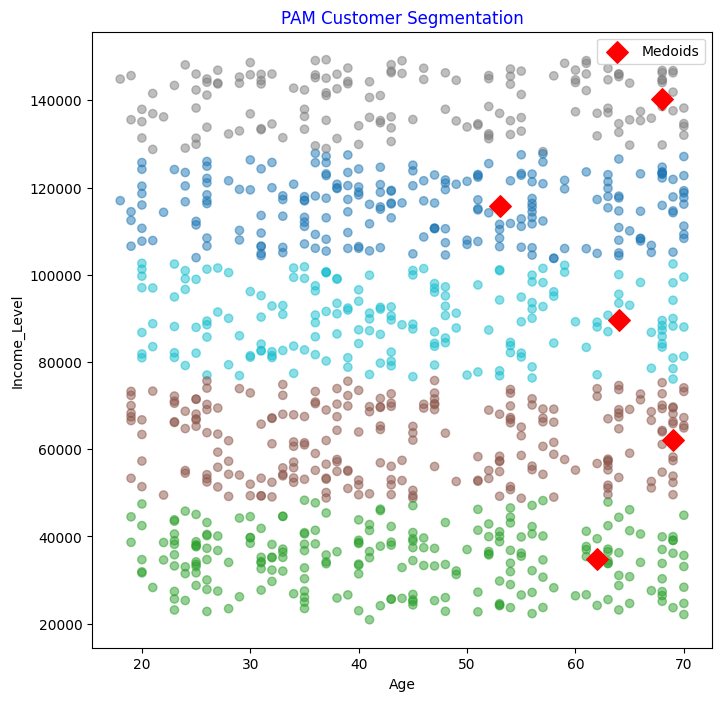

In [11]:
## Biểu diễn trực quan
plt.figure(figsize = (8, 8))
plt.scatter(data2d.Age, data2d['Income_Level'], c = data2d.cluster, alpha = 0.5, cmap = 'tab10')
plt.scatter(medoids2d[:, 0], medoids2d[:, 1], marker = 'D', s = 120, color = 'red', zorder = 5, label = 'Medoids')
plt.xlabel('Age')
plt.ylabel('Income_Level')
plt.title('PAM Customer Segmentation', color = 'blue')
plt.legend()
plt.show()